# Multiscale Effects of Dust on UV Emission at z = 10

This notebook is part of the **CCDC26 tutorial** on how to model the multiscale
effects of dust on galaxy emission from UV to FIR.

The story spans multiple orders of magnitude in scale:

1. **Microscopic — grain size and composition**: grain size and material determine the
   wavelength-dependent absorption/scattering efficiency κ(λ)
2. **Radiative transfer on galaxy scale — geometry and attenuation**: how the spatial distribution of dust
   relative to stars (point-source screen vs. mixed sphere) controls how much UV escapes;
   how MW-like grains (processed, small-grain tail) attenuate more than freshly-produced
   stellar dust (lognormal, peaked at larger grains)
3. **Cosmological-scale — UV luminosity functions at z=10**: applying stellar emission and dust physics to the halo
   mass function obtaining predictions for the number density of galaxies at a given UV magnitude across cosmic time (UV LF)
4. **Morphology and turbulence — galaxy scale scatter and its impact on cosmological scales**: galaxy-to-galaxy variance from halo spin
   (disk size), and line-of-sight variance from turbulent ISM porosity (Mach number) can significantly change the UV LF

**Sections:**
1. Single-grain κ(λ) — grain size and wavelength dependence
2. GSD and integrated κ(λ) — MW (WD01) vs stellar (lognormal) dust
3. RT attenuation curves — PS vs mixed-sphere geometry
4. Save dust constants to `data/dust_constants.txt`
5. UV LF at z=10 — intrinsic (Park+18) + attenuated for each dust model
6. Σ_d and M_UV distributions — spin-driven size scatter vs turbulent LOS scatter
7. Turbulent UV LF — porous ISM via lognormal Σ_d CDF method

*Companion notebook: `notebook_dust_lf_cph26_z7.ipynb` extends to z=7 and adds IR LF and
greybody SED predictions (ALMA observability, T_dust, REBELS data).*

**Output:** `data/dust_constants.txt` (read by `notebooks/main.py`)

In [33]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.lines import Line2D

from dust_jwst_highz import constants as const
from dust_jwst_highz.data import save_dust_constants
from dust_jwst_highz.model.dust import disk_scale_length
from dust_jwst_highz.model.halo import halo_mass_function
from dust_jwst_highz.model.dust import (
    attenuation_curve_li08,
    attenuation_curve_rt,
    attenuation_curve_sommovigo25,
    compute_g_lambda,
    f_curvature,
    grain_size_dist,
    kappa_lambda,
    mass_absorption_coefficient,
    small_carbonaceous_grain_dist,
    stellar_grain_size_dist,
    transmission_sphere,
    transmission_sphere_mixed,
)

try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path().resolve()
DATA_DIR = (_HERE / "../data").resolve()

# Grain material densities [g/cm³]
RHO_CARB = 2.24   # graphite
RHO_SIL  = 3.5    # silicate

# Grain mixture weighting.
# False (default): WD01 / Draine+03 — the per-H-atom dn/da already encodes
#   the relative abundances of carbonaceous and silicate grains, so kappa
#   components are summed directly (no mass-fraction weighting).
# True: as in Sommovigo+25 — applies F_C=1/11, F_SI=10/11 mass fractions
#   to carbonaceous and silicate kappa before combining.
# NOTE: this flag only affects WD01 dust (MW). For stellar dust the
# lognormal GSD is mass-normalised and always needs F_C/F_SI weighting.
LEGACY_MASS_FRACTIONS = False

# Carbon mass fraction in total dust (Draine 2003)
F_C  = 1.0 / 11.0
F_SI = 1.0 - F_C

In [34]:
# ── Load Draine Q tables from CSV ────────────────────────────────────────────
# Each CSV is long-format: (radius[µm], wavelength[µm], Q_abs, Q_sca, g, ...)
# We pivot to (Na, Nλ) arrays.

def _pivot_draine(df):
    """Return radii [µm], wavelength [µm], and Q arrays as (Na, Nλ)."""
    radii = np.sort(df["radius"].unique())       # µm
    wav   = df[df["radius"] == radii[0]]["wavelength"].values  # µm
    q_cols = [c for c in df.columns if c not in ("radius", "wavelength")]
    out = {"radii": radii, "wavelength": wav}
    for col in q_cols:
        arr = np.stack([df[df["radius"] == r][col].values for r in radii])
        out[col] = arr   # (Na, Nλ)
    return out

pah  = _pivot_draine(pd.read_csv(DATA_DIR / "dust_PAH.csv",      comment="#"))
gra  = _pivot_draine(pd.read_csv(DATA_DIR / "dust_graphite.csv", comment="#"))
sil  = _pivot_draine(pd.read_csv(DATA_DIR / "dust_silicate.csv", comment="#"))

radii_c = gra["radii"]         # µm, shape (Na_c,)
radii_s = sil["radii"]         # µm, shape (Na_s,)
wavelength_c = gra["wavelength"]   # µm, shape (Nλ,) — same as silicate
Qabs_c = gra["Q_abs"]          # (Na_c, Nλ)
Qsca_c = gra["Q_sca"]          # (Na_c, Nλ)
g_c    = gra["g"]              # (Na_c, Nλ)
Qabs_s = sil["Q_abs"]          # (Na_s, Nλ)
Qsca_s = sil["Q_sca"]          # (Na_s, Nλ)
g_s    = sil["g"]              # (Na_s, Nλ)

lam_um = wavelength_c          # alias for clarity
lam_A  = lam_um * 1e4          # µm → Å

# V-band and UV indices
i_V  = np.argmin(np.abs(lam_A - 5500.0))
i_UV = np.argmin(np.abs(lam_A - 1500.0))

print(f"Graphite: {len(radii_c)} radii,  {len(wavelength_c)} wavelengths")
print(f"Silicate: {len(radii_s)} radii,  {len(lam_um)} wavelengths")

Graphite: 21 radii,  241 wavelengths
Silicate: 21 radii,  241 wavelengths


## Section 1: Single-grain κ(λ) — grain size and wavelength dependence

The absorption opacity κ_abs scales roughly as λ⁻² (Rayleigh regime) for grains with
a ≪ λ, transitioning to a flatter λ⁻¹ slope (geometric regime) for a ~ λ.

**Key point**: at 1500 Å (UV), small grains (a ~ 0.005 µm) are deep in the Rayleigh
regime with κ_abs ∝ λ⁻¹, while large grains (a ~ 0.3 µm) approach geometric saturation.
The **grain size distribution** therefore strongly controls the total UV opacity:
- **MW dust (WD01)**: power-law extending to very small grains → high UV κ_abs
- **Stellar dust (H19)**: lognormal peaked at a ~ 0.1 µm → lower UV-to-optical ratio

This microscopic picture is the physical foundation for comparing the two bracketing models.

<>:40: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:40: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/wy/syccbmyx2wjb0tf_cks185fh0000gn/T/ipykernel_75574/1801684044.py:40: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  label="Geometric $\propto$ const.")


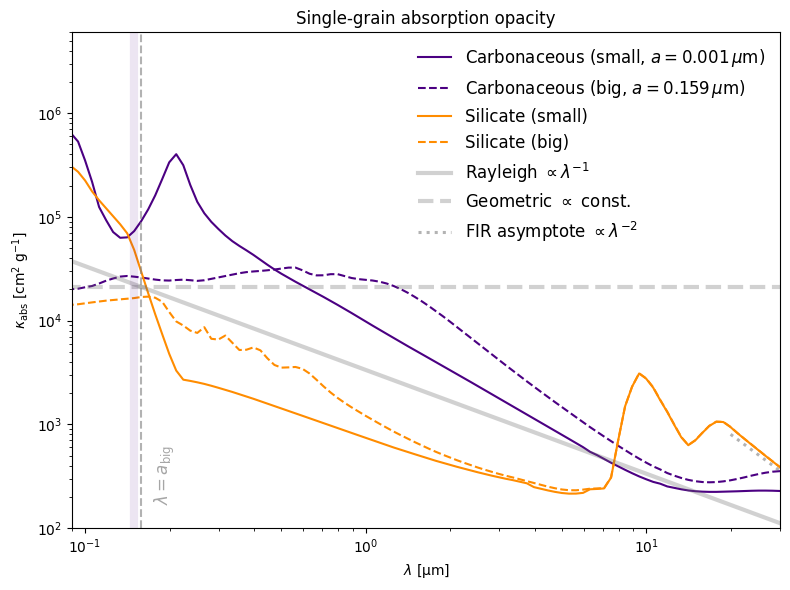

In [35]:
idx_small = 0    # smallest radius in table
idx_big   = 11   # radius ~ 0.3 µm (where stellar GSD peaks)

a_small_c = radii_c[idx_small]   # µm
a_big_c   = radii_c[idx_big]

a_small_s = radii_s[idx_small]
a_big_s   = radii_s[idx_big]

# mass_absorption_coefficient expects radius in cm, Q_abs scalar/array per λ
a_small_c_cm = a_small_c * 1e-4
a_big_c_cm   = a_big_c   * 1e-4
a_small_s_cm = a_small_s * 1e-4
a_big_s_cm   = a_big_s   * 1e-4

kappa_c_small = mass_absorption_coefficient(a_small_c_cm, Qabs_c[idx_small], RHO_CARB)
kappa_c_big   = mass_absorption_coefficient(a_big_c_cm,   Qabs_c[idx_big],   RHO_CARB)
kappa_s_small = mass_absorption_coefficient(a_small_s_cm, Qabs_s[idx_small], RHO_SIL)
kappa_s_big   = mass_absorption_coefficient(a_big_s_cm,   Qabs_s[idx_big],   RHO_SIL)

# Asymptotic scalings
k_geo_b = 3 / (4 * RHO_CARB * a_big_c_cm)
k_ray   = 3 / (4 * RHO_CARB * a_small_c_cm) * (a_small_c / lam_um)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(lam_um, kappa_c_small, color="indigo",     ls="-",
          label=fr"Carbonaceous (small, $a=0.001\,\mu$m)")
ax.loglog(lam_um, kappa_c_big,   color="indigo",     ls="--",
          label=fr"Carbonaceous (big, $a=0.159\,\mu$m)")
ax.loglog(lam_um, kappa_s_small, color="darkorange", ls="-",
          label=fr"Silicate (small)")
ax.loglog(lam_um, kappa_s_big,   color="darkorange", ls="--",
          label=fr"Silicate (big)")
ax.axvline(a_big_c, color="grey", alpha=0.6, lw=1.5, ls="--")
ax.text(a_big_c * 1.1, 200, r"$\lambda=a_{\rm big}$", rotation=90,
        color="grey", alpha=0.7, fontsize=12)
ax.loglog(lam_um, k_ray,                lw=3, alpha=0.3, color="dimgrey",
          label=r"Rayleigh $\propto\lambda^{-1}$")
ax.hlines(k_geo_b, 1e-4, 1e3, lw=3, ls="--", alpha=0.3, color="dimgrey",
          label="Geometric $\propto$ const.")
ax.axvline(0.1500, lw=6, color="indigo", alpha=0.1)
lam_fir = np.linspace(20, 1000, 100)
ax.loglog(lam_fir, 12.85 * (lam_fir / 158.0) ** (-2), color="dimgrey", ls=":", lw=2.2, alpha=0.5,
          label=r"FIR asymptote $\propto \lambda^{-2}$ ")
ax.set_xlabel(r"$\lambda$ [µm]")
ax.set_ylabel(r"$\kappa_{\rm abs}$ [cm$^2$ g$^{-1}$]")
ax.legend(frameon=False, fontsize=12, loc="upper right")
ax.set_xlim(0.090, 30)
ax.set_ylim(1e2, 0.6e7)
ax.set_title("Single-grain absorption opacity")
plt.tight_layout()
plt.show()

## Section 2: GSD and integrated κ(λ) — MW (WD01) vs stellar (lognormal)

Integrate over the full grain size distribution to get the population-averaged opacity κ(λ):

- **MW dust (WD01)**: power-law + carbonaceous bump → high UV κ_abs, prominent 2175 Å feature
- **Stellar dust (Hirashita+2019)**: lognormal at larger a → lower UV/optical opacity ratio,
  less UV curvature

**Physical evolution**: as a galaxy matures, freshly produced SN/AGB grains (stellar GSD)
are processed by ISM shocks and shattering, shifting the GSD toward the MW power-law.
This sets a **lower bound** (stellar) and **upper bound** (MW) on UV attenuation at fixed M_dust.

*Link to Desika's tutorial*: zoom-in/high resolution simulations with dynamical dust models consistently evolve different dust sizes/composition bins
and their processing in the ISM — here we attempt to bracket that evolution with these two "extreme" models.

κ_ext(1500 Å) MW WD01 = 105882 cm² g⁻¹
κ_ext(1500 Å) Stellar  = 8078 cm² g⁻¹

κ_abs(1500 Å) MW      = 59121 cm² g⁻¹
κ_abs(1500 Å) Stellar = 3995 cm² g⁻¹
Saving fig_dust_gsd_kappa_comparison.pdf


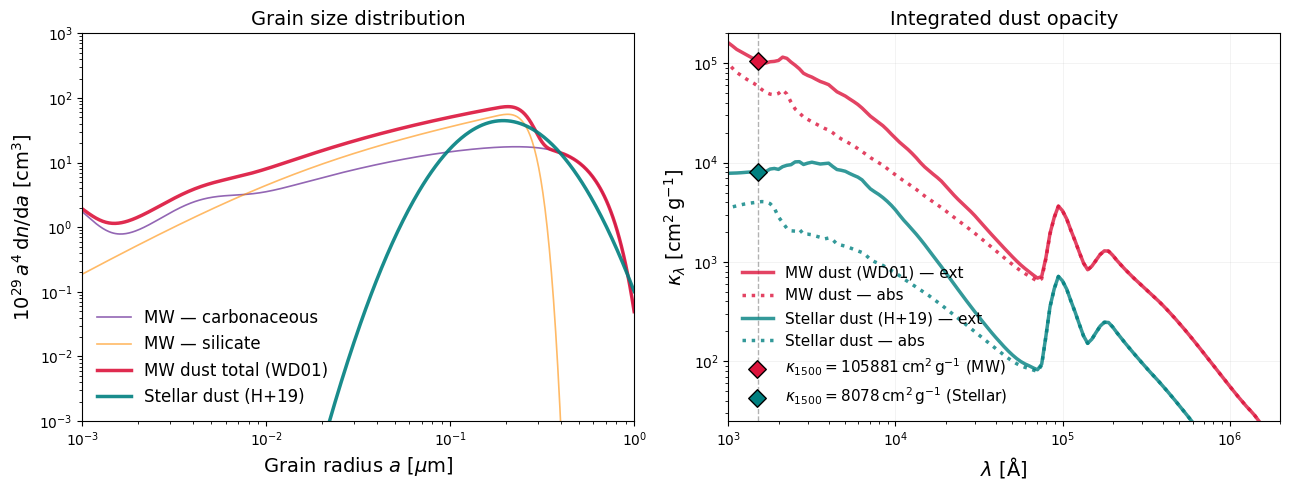

In [36]:
# Load WD01 MW parameters (RV=3.1, case A, bC index 2 → bC=2×10⁻⁵)
with open(DATA_DIR / "wd01_mw_gsd_params.yaml") as f:
    wd01 = yaml.safe_load(f)

p = wd01["3.1"]["A"][2]   # bC = 2.0 → bc = 2e-5

# Convert µm → cm for grain_size_dist
at_g_cm = p["graphite"]["at"] * 1e-4
ac_g_cm = p["graphite"]["ac"] * 1e-4
at_s_cm = p["silicate"]["at"] * 1e-4
ac_s_cm = 0.1e-4                       # WD01: fixed a_c,s = 0.1 µm

# Evaluate WD01 dn/da on the Draine Q-table radius grids (in cm)
a_c_cm = radii_c * 1e-4   # µm → cm
a_s_cm = radii_s * 1e-4

dn_da_C_grd  = grain_size_dist(
    a_c_cm,
    c=p["graphite"]["c"], at=at_g_cm, ac=ac_g_cm,
    alpha=p["graphite"]["alpha"], beta=p["graphite"]["beta"],
    d_func=lambda a: small_carbonaceous_grain_dist(a, bc=2.0e-5),
)
dn_da_Si_grd = grain_size_dist(
    a_s_cm,
    c=p["silicate"]["c"], at=at_s_cm, ac=ac_s_cm,
    alpha=p["silicate"]["alpha"], beta=p["silicate"]["beta"],
)

# κ per component — kappa_lambda expects radius in cm, q_abs_table (Na, Nλ)
kappa_c_abs = kappa_lambda(a_c_cm, Qabs_c, dn_da_C_grd)
kappa_c_sca = kappa_lambda(a_c_cm, Qsca_c, dn_da_C_grd)
kappa_s_abs = kappa_lambda(a_s_cm, Qabs_s, dn_da_Si_grd)
kappa_s_sca = kappa_lambda(a_s_cm, Qsca_s, dn_da_Si_grd)

# Total MW mixture
if LEGACY_MASS_FRACTIONS:
    kappa_abs_tot = F_C * kappa_c_abs + F_SI * kappa_s_abs
    kappa_sca_tot = F_C * kappa_c_sca + F_SI * kappa_s_sca
else:
    # WD01 dn/da per H already encodes relative abundances — direct sum
    kappa_abs_tot = kappa_c_abs + kappa_s_abs
    kappa_sca_tot = kappa_c_sca + kappa_s_sca
kappa_ext_tot = kappa_abs_tot + kappa_sca_tot
omega_tot     = kappa_sca_tot / kappa_ext_tot

kUV_drn = float(kappa_ext_tot[i_UV])
print(f"κ_ext(1500 Å) MW WD01 = {kUV_drn:.0f} cm² g⁻¹")

# Stellar lognormal GSD (Hirashita-style)
# stellar_grain_size_dist returns mass-normalised φ(a); convert to dn/da [per H]
factor_C  = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0*np.pi/3.0) * RHO_CARB)
factor_Si = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0*np.pi/3.0) * RHO_SIL)

phi_C_star  = stellar_grain_size_dist(a_c_cm, a0_cm=1e-5, sigma=0.47)
phi_Si_star = stellar_grain_size_dist(a_s_cm, a0_cm=1e-5, sigma=0.47)

dn_da_C_star  = factor_C  * phi_C_star
dn_da_Si_star = factor_Si * phi_Si_star

# Stellar κ — always needs F_C/F_SI (mass-normalised GSD)
kappa_C_abs_star  = kappa_lambda(a_c_cm, Qabs_c, F_C  * dn_da_C_star)
kappa_C_sca_star  = kappa_lambda(a_c_cm, Qsca_c, F_C  * dn_da_C_star)
kappa_Si_abs_star = kappa_lambda(a_s_cm, Qabs_s, F_SI * dn_da_Si_star)
kappa_Si_sca_star = kappa_lambda(a_s_cm, Qsca_s, F_SI * dn_da_Si_star)

kappa_abs_star_tot = kappa_C_abs_star + kappa_Si_abs_star
kappa_sca_star_tot = kappa_C_sca_star + kappa_Si_sca_star
kappa_ext_star_tot = kappa_abs_star_tot + kappa_sca_star_tot
omega_star_tot     = kappa_sca_star_tot / kappa_ext_star_tot

kUV_hir = float(kappa_ext_star_tot[i_UV])
print(f"κ_ext(1500 Å) Stellar  = {kUV_hir:.0f} cm² g⁻¹")

# Asymmetry parameter g(λ) — compute_g_lambda expects radii in µm
g_c_MW   = compute_g_lambda(radii_c, Qsca_c, g_c, dn_da_C_grd)
g_s_MW   = compute_g_lambda(radii_s, Qsca_s, g_s, dn_da_Si_grd)
if LEGACY_MASS_FRACTIONS:
    w_c_mw = F_C  * kappa_c_sca
    w_s_mw = F_SI * kappa_s_sca
else:
    w_c_mw = kappa_c_sca
    w_s_mw = kappa_s_sca
g_tot_MW = (g_c_MW * w_c_mw + g_s_MW * w_s_mw) / (w_c_mw + w_s_mw)

# Stellar g — always needs F_C/F_SI (mass-normalised GSD)
g_c_star   = compute_g_lambda(radii_c, Qsca_c, g_c, F_C  * dn_da_C_star)
g_s_star   = compute_g_lambda(radii_s, Qsca_s, g_s, F_SI * dn_da_Si_star)
w_c_star   = kappa_C_sca_star
w_s_star   = kappa_Si_sca_star
g_tot_star = (g_c_star * w_c_star + g_s_star * w_s_star) / (w_c_star + w_s_star)

print(f"\nκ_abs(1500 Å) MW      = {kappa_abs_tot[i_UV]:.0f} cm² g⁻¹")
print(f"κ_abs(1500 Å) Stellar = {kappa_abs_star_tot[i_UV]:.0f} cm² g⁻¹")

# ── Side-by-side: GSD (left) + κ(λ) (right) ─────────────────────────────────
# Fine grid for smooth GSD curves (the Draine Q-table grids are coarse)
a_plot = np.logspace(np.log10(3.5e-8), np.log10(1e-4), 600)  # cm

dn_C_plot  = grain_size_dist(
    a_plot,
    c=p["graphite"]["c"], at=at_g_cm, ac=ac_g_cm,
    alpha=p["graphite"]["alpha"], beta=p["graphite"]["beta"],
    d_func=lambda a: small_carbonaceous_grain_dist(a, bc=2.0e-5),
)
dn_Si_plot = grain_size_dist(
    a_plot,
    c=p["silicate"]["c"], at=at_s_cm, ac=ac_s_cm,
    alpha=p["silicate"]["alpha"], beta=p["silicate"]["beta"],
)
dn_star_C_plot  = factor_C  * stellar_grain_size_dist(a_plot, a0_cm=1e-5, sigma=0.47)
dn_star_Si_plot = factor_Si * stellar_grain_size_dist(a_plot, a0_cm=1e-5, sigma=0.47)

fig, (ax_gsd, ax_kap) = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: GSD — thin lines for MW components, thick crimson for MW total, teal for stellar
ax_gsd.loglog(a_plot * 1e4, 1e29 * a_plot**4 * dn_C_plot,
              color="indigo",     lw=1.2, alpha=0.6, label="MW — carbonaceous")
ax_gsd.loglog(a_plot * 1e4, 1e29 * a_plot**4 * dn_Si_plot,
              color="darkorange", lw=1.2, alpha=0.6, label="MW — silicate")
ax_gsd.loglog(a_plot * 1e4, 1e29 * a_plot**4 * (dn_C_plot + dn_Si_plot),
              color="crimson",    lw=2.5, alpha=0.9, label="MW dust total (WD01)")
ax_gsd.loglog(a_plot * 1e4, 1e29 * a_plot**4 * (dn_star_C_plot + dn_star_Si_plot),
              color="teal",       lw=2.5, alpha=0.9, label="Stellar dust (H+19)")
ax_gsd.set_xlim(1e-3, 1.0)
ax_gsd.set_ylim(1e-3, 1e3)
ax_gsd.set_xlabel(r"Grain radius $a\ [\mu{\rm m}]$", fontsize=14)
ax_gsd.set_ylabel(r"$10^{29}\,a^4\,{\rm d}n/{\rm d}a\ [{\rm cm}^3]$", fontsize=14)
ax_gsd.legend(frameon=False, fontsize=12)
#ax_gsd.grid(True, which="both", ls=":", alpha=0.3)
ax_gsd.set_title("Grain size distribution", fontsize=14)

# Right panel: κ(λ) comparison — solid=ext, dotted=abs
ax_kap.plot(lam_A, kappa_ext_tot,      lw=2.5, alpha=0.8, color="crimson",
            label="MW dust (WD01) — ext")
ax_kap.plot(lam_A, kappa_abs_tot,      lw=2.5, alpha=0.8, color="crimson", ls=":",
            label="MW dust — abs")
ax_kap.plot(lam_A, kappa_ext_star_tot, lw=2.5, alpha=0.8, color="teal",
            label="Stellar dust (H+19) — ext")
ax_kap.plot(lam_A, kappa_abs_star_tot, lw=2.5, alpha=0.8, color="teal", ls=":",
            label="Stellar dust — abs")
ax_kap.scatter([1500], [kUV_drn], color="crimson", edgecolor="black", s=80, marker="D",
               zorder=5, label=fr"$\kappa_{{1500}}={int(kUV_drn)}\,\rm cm^2\,g^{{-1}}$ (MW)")
ax_kap.scatter([1500], [kUV_hir], color="teal",    edgecolor="black", s=80, marker="D",
               zorder=5, label=fr"$\kappa_{{1500}}={int(kUV_hir)}\,\rm cm^2\,g^{{-1}}$ (Stellar)")
ax_kap.axvline(1500.0, color="gray", ls="--", lw=1, alpha=0.6)
ax_kap.set_xscale("log")
ax_kap.set_yscale("log")
ax_kap.set_ylim(25, 2e5)
ax_kap.set_xlim(1e3, 2e6)
ax_kap.set_xlabel(r"$\lambda\ [\mathrm{\AA}]$", fontsize=14)
ax_kap.set_ylabel(r"$\kappa_\lambda\ [{\rm cm}^2\,{\rm g}^{-1}]$", fontsize=14)
ax_kap.grid(True, alpha=0.2, lw=0.5)
ax_kap.legend(frameon=False, fontsize=11, loc="lower left")
ax_kap.set_title("Integrated dust opacity", fontsize=14)

plt.tight_layout()
print("Saving fig_dust_gsd_kappa_comparison.pdf")
#fig.savefig(DATA_DIR / "../outputs/fig_dust_gsd_kappa_comparison.pdf", bbox_inches="tight")
plt.show()

## Section 3: RT attenuation curves — geometry connects grains to observables

Given κ(λ), the *observed* attenuation also depends on where the dust sits relative to the stars:

- **Point-source (PS) screen**: stars behind a uniform dust slab.  
  Transmission T = exp(−κ Σ_d). Yields the steepest A_λ/A_V curves.
- **Mixed sphere**: dust and stars uniformly mixed within a sphere.  
  The path-averaged transmission T_mix < exp(−τ), producing a **greyer** attenuation curve
  because blue photons see a distribution of path lengths rather than a single τ.

Mixed-sphere geometry is a better approximation for galaxies where stars and dust
are co-spatial.

*Link to Desika's tutorial*: In an actual simulation with radiative transfer (RT) on the fly or in post-processing (and/or emulator), these functional forms are not needed as the RT code used takes care of correctly accounting for the deviation from extinction curve to attenuation curve along a given line of sight. 

Saving fig_attenuation_curves.pdf


/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/dust.py:985: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(t_lam)
/Users/laurasommovigo/Desktop/dust_JWST_highz/src/dust_jwst_highz/model/dust.py:985: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(t_lam)


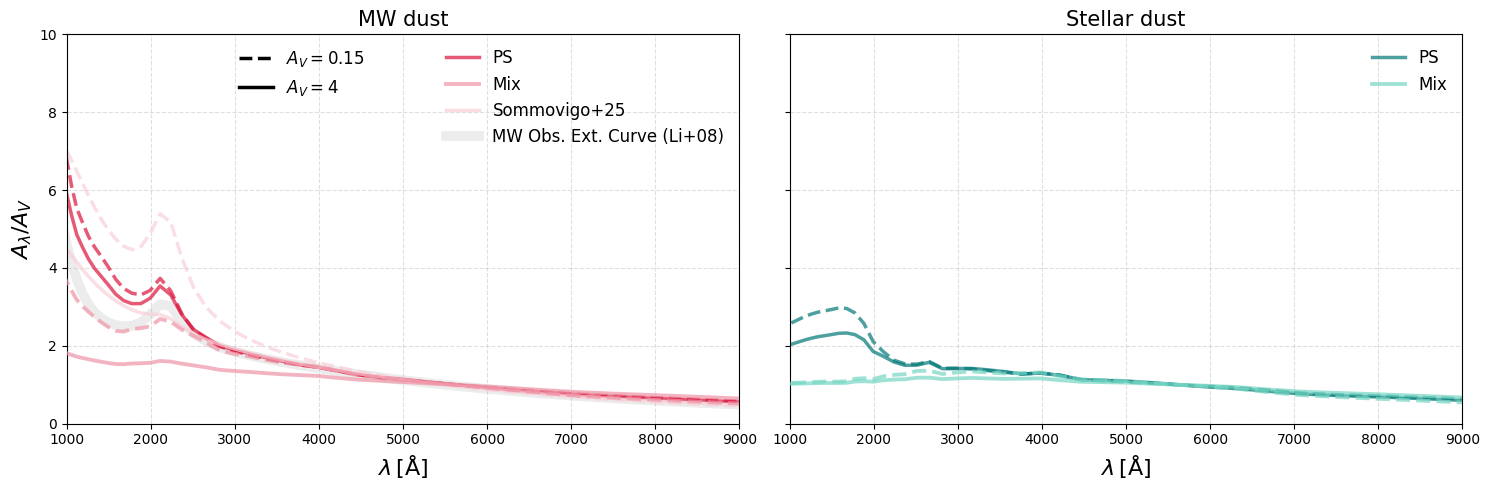

In [37]:
Av_values = [0.15, 4.0]
ls_map    = {0.15: "--", 4.0: "-"}
lw_map    = {0.15: 2.5, 4.0: 2.5}

def _sigmad_from_av(av, kappa_v):
    """Convert screen A_V to dust surface density [g/cm²]."""
    return av / (kappa_v * (2.5 / np.log(10)))

def _make_shades(base_color):
    base = np.array(matplotlib.colors.to_rgb(base_color))
    return [tuple(1 - f * (1 - base)) for f in [1.0, 0.45, 0.2]]

def plot_family(ax, kappa_ext, omega, g, color, title):
    kappa_v = kappa_ext[i_V]
    shade_ps, shade_mix, shade_s25 = _make_shades(color)
    if title == "Stellar dust":
        shade_ps  = "#027876"
        shade_mix = "#76d7c4"

    for av in Av_values:
        lw = lw_map[av]
        sigmad = _sigmad_from_av(av, kappa_v)

        # Point-source (sphere_central)
        A_ps = attenuation_curve_rt(kappa_ext, omega, g, sigmad,
                                     geometry="sphere_central")
        A_ps_norm = A_ps / A_ps[i_V]
        ax.plot(lam_A, A_ps_norm, color=shade_ps, lw=lw, ls=ls_map[av], alpha=0.7,
                label="PS" if np.isclose(av, Av_values[1]) else None)

        # Mixed (sphere_mixed)
        A_mix = attenuation_curve_rt(kappa_ext, omega, g, sigmad,
                                      geometry="sphere_mixed")
        A_mix_norm = A_mix / A_mix[i_V]
        ax.plot(lam_A, A_mix_norm, color=shade_mix, lw=1.1*lw, ls=ls_map[av], alpha=0.7,
                label="Mix" if np.isclose(av, Av_values[1]) else None, zorder=1000)

        # Sommovigo+25 parametric (MW panel only)
        if title == "MW dust":
            A_s25 = attenuation_curve_sommovigo25(lam_um, av)
            ax.plot(lam_A, A_s25, color=shade_s25, lw=lw, ls=ls_map[av], alpha=0.7,
                    label="Sommovigo+25" if np.isclose(av, Av_values[1]) else None)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r"$\lambda\,[\mathrm{\AA}]$", fontsize=16)
    ax.grid(alpha=0.4, ls="--")

fig, (ax_mw, ax_st) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
plt.subplots_adjust(wspace=0)

plot_family(ax_mw, kappa_ext_tot,      omega_tot,      g_tot_MW,   "crimson", "MW dust")
plot_family(ax_st, kappa_ext_star_tot, omega_star_tot, g_tot_star, "teal",    "Stellar dust")

# MW extinction curve overlay
ax_mw.plot(lam_A, attenuation_curve_li08(lam_um, 0, 0, 0, 0, model="MW"),
           color="gray", lw=7, alpha=0.15, label="MW Obs. Ext. Curve (Li+08)",
           zorder=-10000)

for ax in (ax_mw, ax_st):
    ax.set_xlim(1e3, 9e3)

ax_mw.set_ylabel(r"$A_\lambda/A_V$", fontsize=16)
ax_mw.set_ylim(0, 10)

# A_V legend
av_handles = [Line2D([0], [0], color="k", lw=2.5, ls=ls_map[av],
                     label=f"$A_V={av:g}$")
              for av in Av_values]
leg_av = ax_mw.legend(handles=av_handles, loc="upper center",
                      bbox_to_anchor=(0.35, 1.0), fontsize=12, frameon=False)

# Model legend (unique labels only)
def _unique_legend(ax, **kwargs):
    handles, labels = ax.get_legend_handles_labels()
    seen, h_out, l_out = set(), [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            seen.add(l); h_out.append(h); l_out.append(l)
    ax.legend(h_out, l_out, **kwargs)

_unique_legend(ax_mw, loc="upper right", fontsize=12, frameon=False)
ax_mw.add_artist(leg_av)
_unique_legend(ax_st, loc="upper right", fontsize=12, frameon=False)

plt.tight_layout()
print("Saving fig_attenuation_curves.pdf")
#fig.savefig(DATA_DIR / "../outputs/fig_attenuation_curves.pdf", bbox_inches="tight")
plt.show()

## Section 4: Save dust constants to `data/dust_constants.txt`

Store κ_UV, κ_V (ext), and κ_IR at 158 µm for both dust models so that subsequent
sections and `notebooks/main.py` can load them without re-running the GSD integration.

In [38]:
kUV_drn_abs = float(kappa_abs_tot[i_UV])
kUV_hir_abs = float(kappa_abs_star_tot[i_UV])
kv_drn      = float(kappa_ext_tot[i_V])
kv_hir      = float(kappa_ext_star_tot[i_V])

# IR opacity at 158 µm (1.58e6 Å)
i_IR_drn = np.argmin(np.abs(lam_A - 1.585e6))
i_IR_hir = np.argmin(np.abs(lam_A - 1.585e6))
kIR_drn = float(kappa_abs_tot[i_IR_drn])
kIR_hir = float(kappa_abs_star_tot[i_IR_hir])

omega_1500_drn = float(omega_tot[i_UV])
omega_1500_hir = float(omega_star_tot[i_UV])
g_1500_drn     = float(g_tot_MW[i_UV])
g_1500_hir     = float(g_tot_star[i_UV])

constants = {
    "kUV_drn":       kUV_drn,
    "kUV_drn_abs":   kUV_drn_abs,
    "kv_drn":        kv_drn,
    "kIR_drn":       kIR_drn,
    "omega_1500_drn": omega_1500_drn,
    "g_1500_drn":    g_1500_drn,
    "kUV_hir":       kUV_hir,
    "kUV_hir_abs":   kUV_hir_abs,
    "kv_hir":        kv_hir,
    "kIR_hir":       kIR_hir,
    "omega_1500_hir": omega_1500_hir,
    "g_1500_hir":    g_1500_hir,
}

save_dust_constants(constants)
print("\n==== Saved dust_constants.txt ====")
for k, v in constants.items():
    print(f"  {k:<20} {v:.4f}")


==== Saved dust_constants.txt ====
  kUV_drn              105881.5624
  kUV_drn_abs          59121.1205
  kv_drn               41153.3936
  kIR_drn              21.9991
  omega_1500_drn       0.4416
  g_1500_drn           0.6467
  kUV_hir              8078.4672
  kUV_hir_abs          3994.6991
  kv_hir               7443.5715
  kIR_hir              3.1871
  omega_1500_hir       0.5055
  g_1500_hir           0.8316


## Section 5: UV LF at z=10 — from grain physics to galaxy populations

Apply the two dust models to the **Park et al. (2018)** semi-analytic UV LF:

  SFR = (f★/t★) × (Ωb/Ωm) × Mh × (Mh/10¹⁰)^α,  L_UV via Kennicutt+98
  Σ_d ∝ f_d × ε × (Ωb/Ωm) × Mh / (π r_d²),  r_d from spin + virial radius

The UV LF maps how dust dims different parts of the mass function:
MW dust (κ_UV,MW > κ_UV,stellar) suppresses the bright end more strongly.

**Physical message**: observing the UV LF at z ~ 7–10 with JWST constrains which dust
grain model is more representative of high-z ISMs.

Saving fig_uvlf_dust_comparison.pdf


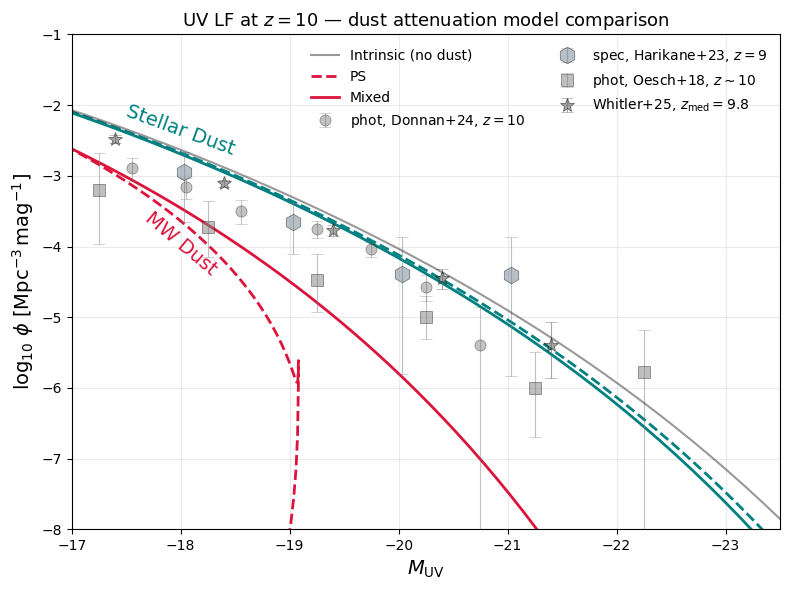

In [39]:
from astropy.cosmology import Planck18 as _cosmo
from astropy import units as _u

z_lf = 10.0

# ── Park+18 parameters ──────────────────────────────────────────────────────
KUV    = 1.15e-28            # Kennicutt: SFR [M☉/yr] = L_UV [erg/s/Hz] * KUV
OMm    = _cosmo.Om0
OMl    = _cosmo.Ode0
Omb    = _cosmo.Ob0
hlittle = _cosmo.h
H0_h   = _cosmo.H0.value / 100.0   # dimensionless h

fs_ts  = 0.15                # f★ / t★  (increased from Park+18 fiducial 0.02 to match z=10 obs)
alpha_p = 0.3                # SFR power-law slope
Mturn  = 1e9                 # duty-cycle turnover mass [M☉]

# Hubble rate at z [yr⁻¹] — Park+18 eq. (used in SFR formula)
Hz_yr  = 3.09 * H0_h * (OMm * (1 + z_lf)**1.5 + OMl**0.5)   # Park+18 units (absorbed into fs_ts)

# Halo mass grid
masse  = 10.0 ** np.arange(8.0, 13.5, 0.05)   # M☉

# ── Intrinsic MUV ────────────────────────────────────────────────────────────
SFR    = fs_ts * (masse / 1e10)**(alpha_p + 1) * (Omb / OMm) * Hz_yr  # M☉/yr
L_UV   = SFR / KUV                                                      # erg/s/Hz
# m_AB = -2.5 log10(f_nu) - 48.6, at d=10pc  →  M_UV from L_UV
# M_UV = -2.5 * log10(L_UV / (4π (10 pc)²)) - 48.6
# equivalently: M_UV = -(log10(L_UV) - 0.4*51.63) / 0.4
MUV_intr = -(np.log10(L_UV) - 0.4 * 51.63) / 0.4

# ── Halo mass function dn/dMh [Mpc⁻³ M☉⁻¹] ─────────────────────────────────
dndm = halo_mass_function(masse, z_lf)

# Duty cycle
f_duty = np.exp(-Mturn / masse)

# Jacobian |dMh / dMUV_intr| (analytical, Park+18 style)
dSFRdMh   = fs_ts * (Omb / OMm) * Hz_yr * (alpha_p + 1) * (masse / 1e10)**alpha_p / 1e10
dLUVdSFR  = 1.0 / KUV
dMUVdLUV  = -1.0 / (0.4 * np.log(10) * L_UV)
dMUVdMh_intr = dMUVdLUV * dLUVdSFR * dSFRdMh   # dMUV_intr/dMh  (negative)

phi_intr = dndm * f_duty * np.abs(1.0 / dMUVdMh_intr)

# ── Dust attenuation ──────────────────────────────────────────────────────────
eps_star = 0.15           # star-formation efficiency — consistent with fs_ts above
f_d      = 8e-4           # dust-to-stellar-mass ratio
spin_mean = np.exp(-3.6)  # mean halo spin parameter

M_star = eps_star * (Omb / OMm) * masse          # M☉
M_dust = f_d * M_star                             # M☉
R_d    = np.array([disk_scale_length(z_lf, m, spin_mean) for m in masse])  # kpc

# Σ_d [g/cm²]: M_dust distributed over (4/3)πRd² (sphere mixed geometry factor)
Sigma_d = M_dust * const.M_sun / ((4.0 / 3.0) * np.pi * R_d**2 * const.kpc**2)

# τ_UV for each dust model
tau_UV_mw = kappa_ext_tot[i_UV]      * Sigma_d   # MW dust
tau_UV_st = kappa_ext_star_tot[i_UV] * Sigma_d   # Stellar dust

# A_UV [mag] for each (dust model) × (geometry)
A_UV_mw_ps  = -2.5 * np.log10(transmission_sphere(tau_UV_mw,
               omega=omega_tot[i_UV], g=g_tot_MW[i_UV]))
A_UV_mw_mix = -2.5 * np.log10(transmission_sphere_mixed(tau_UV_mw))
A_UV_st_ps  = -2.5 * np.log10(transmission_sphere(tau_UV_st,
               omega=omega_star_tot[i_UV], g=g_tot_star[i_UV]))
A_UV_st_mix = -2.5 * np.log10(transmission_sphere_mixed(tau_UV_st))

# Attenuated MUV (fainter = more positive)
MUV_mw_ps  = MUV_intr + A_UV_mw_ps
MUV_mw_mix = MUV_intr + A_UV_mw_mix
MUV_st_ps  = MUV_intr + A_UV_st_ps
MUV_st_mix = MUV_intr + A_UV_st_mix

# Recompute LF with numerical Jacobian |dMUV_att/dMh|
def _phi_att(MUV_att):
    dMUV_dMh = np.gradient(MUV_att, masse)
    return dndm * f_duty * np.abs(1.0 / dMUV_dMh)

phi_mw_ps  = _phi_att(MUV_mw_ps)
phi_mw_mix = _phi_att(MUV_mw_mix)
phi_st_ps  = _phi_att(MUV_st_ps)
phi_st_mix = _phi_att(MUV_st_mix)

import pandas as _pd_lf
from dust_jwst_highz.visualization import PLOTTING_STYLES

df_obs = _pd_lf.read_csv(DATA_DIR / "uv_lf_observations.csv", comment="#")
df_z10 = df_obs[df_obs["redshift"] == 10].copy()

def _plot_obs(ax, df):
    """Plot observational LF points with per-source markers from PLOTTING_STYLES."""
    for src, grp in df.groupby("source"):
        style = PLOTTING_STYLES.get(src, {})
        marker = style.get("marker", "o")
        color  = style.get("color",  "grey")
        # Remap colours that clash with model curves (teal = stellar dust, black = intrinsic LF)
        color  = {"teal": "slategrey", "black": "dimgrey"}.get(color, color)
        ms_raw = style.get("ms",     10)
        ms     = ms_raw if isinstance(ms_raw, (int, float)) else ms_raw.get(10, 10)
        al_raw = style.get("alpha",  0.7)
        alpha  = al_raw if isinstance(al_raw, float) else al_raw.get(10, 0.7)
        lab_raw = style.get("label", {})
        label  = lab_raw.get(10, src) if isinstance(lab_raw, dict) else src
        det = grp[grp["is_upper_limit"] == 0]
        if len(det):
            phi      = det["phi"].values
            phi_lo   = np.clip(phi - det["phi_err_low"].values, 1e-12, None)
            phi_hi   = phi + det["phi_err_up"].values
            ax.errorbar(
                det["muv"], np.log10(phi),
                yerr=[np.log10(phi / phi_lo), np.log10(phi_hi / phi)],
                fmt=marker, color=color, ms=ms, mec="black", mew=0.5,
                capsize=4, elinewidth=0.8, alpha=alpha, label=label,
            )

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Intrinsic LF
ax.plot(MUV_intr, np.log10(phi_intr), color="black", lw=1.5, ls="-",
        label="Intrinsic (no dust)", zorder=10, alpha=0.4)

# Attenuated LFs
ax.plot(MUV_mw_ps,  np.log10(phi_mw_ps),  color="crimson", lw=2, ls="--",
        label="PS")
ax.plot(MUV_mw_mix, np.log10(phi_mw_mix), color="crimson", lw=2, ls="-",
        label="Mixed")
ax.plot(MUV_st_ps,  np.log10(phi_st_ps),  color="teal",    lw=2, ls="--")
ax.plot(MUV_st_mix, np.log10(phi_st_mix), color="teal",    lw=2, ls="-")

# Observational data — per-source markers, black edgecolor (via plot_lf_data)
_plot_obs(ax, df_z10)

ax.text(-18, -4.4,
        "MW Dust", color="crimson", fontsize=14, ha="center",
        rotation=-40)
ax.text(-18, -2.7,
        "Stellar Dust", color="teal", fontsize=14, ha="center",
        rotation=-20)

ax.set_xlabel(r"$M_{\rm UV}$", fontsize=14)
ax.set_ylabel(r"$\log_{10}\,\phi\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$", fontsize=14)
ax.set_xlim(-17.0, -23.5)
ax.set_ylim(-8, -1)
ax.legend(fontsize=10, frameon=False, ncol=2, loc="upper right")
ax.set_title(rf"UV LF at $z={z_lf:.0f}$ — dust attenuation model comparison", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
print("Saving fig_uvlf_dust_comparison.pdf")
#fig.savefig(DATA_DIR / "../outputs/fig_uvlf_dust_comparison.pdf", bbox_inches="tight")
plt.show()

## Section 6: Σ_d and M_UV distributions — morphology and ISM turbulence

For a single representative halo (log Mh = 11.6), we decompose Σ_d scatter into:

1. **Galaxy-to-galaxy scatter (spin parameter λ)**: disk size r_d ∝ λ × r_vir,
   so compact galaxies (low λ) are dustier per unit area by ~0.5 dex.
   This is *morphological* uncertainty — identical halos can have very different τ.

2. **LOS scatter (turbulent Mach number M)**: within one galaxy, turbulence creates
   a log-normal distribution of Σ_d along different sight lines.
   Width σ_ln is a function of Mach number M.  Higher M → more low-τ sight lines → UV-bright tail.

**Tension with JWST**: the excess of UV-bright galaxies at z ~ 10 can be explained
by porous, turbulent ISMs (M ~ 10–100) that let UV photons escape from dusty halos.

Intrinsic MUV at log Mh=10.86: -20.46
Saving fig_sigmad_muv_pdfs.pdf


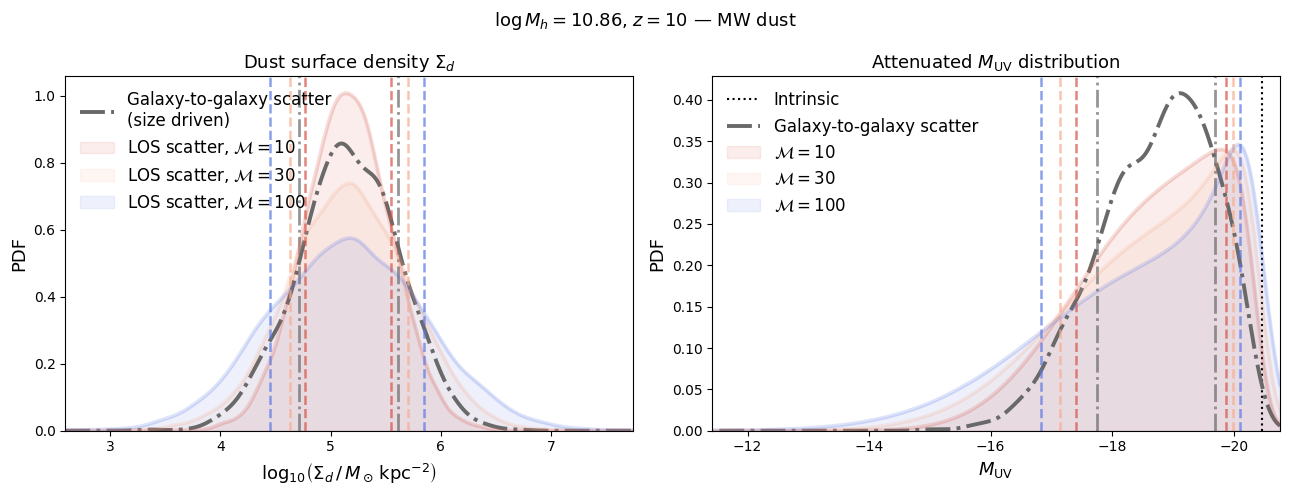

In [40]:
from scipy.stats import norm, gaussian_kde
from dust_jwst_highz.model.ism import lognormal_variance_from_mach, sample_surface_density

# Representative halo (same as main.py)
log_mh_rep = 10.86
mh_rep = 10**log_mh_rep

# Intrinsic L_UV from Park+18 (consistent with Section 5)
sfr_rep = fs_ts * (mh_rep / 1e10)**(alpha_p + 1) * (Omb / OMm) * Hz_yr
l1500_rep = sfr_rep / KUV
muv_intr_rep = -(np.log10(l1500_rep) - 0.4 * 51.63) / 0.4
print(f"Intrinsic MUV at log Mh={log_mh_rep}: {muv_intr_rep:.2f}")

# M_dust consistent with Section 5 recipe
m_star_rep = eps_star * (Omb / OMm) * mh_rep
m_dust_rep  = f_d * m_star_rep

# Spin distribution → geometry-driven Σ_d scatter (1000 draws)
np.random.seed(42)
spin_rep = np.random.lognormal(mean=np.log(10**-1.5677), sigma=0.5390, size=1000)
r_d_rep  = np.array([disk_scale_length(z_lf, mh_rep, lam) for lam in spin_rep])  # kpc
Sigmad_arr_rep = m_dust_rep * const.M_sun / ((4.0/3.0) * np.pi * r_d_rep**2 * const.kpc**2)

# Turbulent LOS Σ_d draws (sample_surface_density from ISM module)
mach_vals_pdf = np.array([10, 30, 100])
Sigmad_clumpy = {m: sample_surface_density(mu_sigma=np.median(Sigmad_arr_rep), mach=m)
                 for m in mach_vals_pdf}

# MUV from spin scatter — uniform ISM, mixed geometry
tau_rep_spin = kappa_ext_tot[i_UV] * Sigmad_arr_rep
muv_att_spin = -2.5 * np.log10(l1500_rep * transmission_sphere_mixed(tau_rep_spin)) + 51.63

# MUV from turbulence — get_muv_clumpy logic (K_SPINS quantile seeds, N_LOS per seed)
K_SPINS = 13
N_LOS   = 600
_u_left  = (np.arange(1, K_SPINS // 2 + 1) - 0.5) / K_SPINS
u_seeds  = np.concatenate([_u_left, [0.5], 1.0 - _u_left[::-1]])

def _get_muv_clumpy(mach, sigmad_arr, u_seeds, n_los, kappa_uv, l_intr):
    sigma_ln  = lognormal_variance_from_mach(mach)
    mu_sigmas = np.quantile(sigmad_arr, u_seeds)              # (K_SPINS,)
    u_los     = (np.arange(1, n_los + 1) - 0.5) / n_los
    z_los     = norm.ppf(u_los)[None, :]                      # (1, N_LOS)
    sig_los   = np.exp(np.log(mu_sigmas)[:, None] + sigma_ln * z_los)  # (K_SPINS, N_LOS)
    luv_los   = l_intr * transmission_sphere_mixed(kappa_uv * sig_los)
    return -2.5 * np.log10(luv_los.ravel()) + 51.63

muv_clumpy_pdf = {m: _get_muv_clumpy(m, Sigmad_arr_rep, u_seeds, N_LOS,
                                      kappa_ext_tot[i_UV], l1500_rep)
                  for m in mach_vals_pdf}

# ── Figure ────────────────────────────────────────────────────────────────────
cmap_mach = plt.cm.coolwarm_r
# Use explicit positions avoiding the white centre of coolwarm_r (~0.5)
# M=10 → deep blue (0.1), M=30 → mid blue (0.3), M=100 → deep red (0.9)
mach_colors_pdf = [cmap_mach(v) for v in [0.1, 0.3, 0.9]]

gcm2_to_msun_kpc2 = const.kpc**2 / const.M_sun
log_sig_spin    = np.log10(Sigmad_arr_rep * gcm2_to_msun_kpc2)
log_sig_clumpy  = {m: np.log10(Sigmad_clumpy[m] * gcm2_to_msun_kpc2) for m in mach_vals_pdf}

all_log_sig = np.concatenate([log_sig_spin] + [log_sig_clumpy[m] for m in mach_vals_pdf])
x_sig = np.linspace(all_log_sig.min(), all_log_sig.max(), 400)

all_muv_pdf = np.concatenate([muv_att_spin] + [muv_clumpy_pdf[m] for m in mach_vals_pdf])
# Extend xlim to include the intrinsic MUV (which is brighter / more negative)
x_muv_pdf   = np.linspace(min(all_muv_pdf.min(), muv_intr_rep) - 0.3, all_muv_pdf.max(), 400)

fig, (ax_sig, ax_muv) = plt.subplots(1, 2, figsize=(13, 5))

sig_data   = [log_sig_spin] + [log_sig_clumpy[m] for m in mach_vals_pdf]
muv_data   = [muv_att_spin] + [muv_clumpy_pdf[m] for m in mach_vals_pdf]
colors_pdf = ["dimgrey"] + list(mach_colors_pdf)
labels_sig = ["Galaxy-to-galaxy scatter\n(size driven)"] + \
             [fr"LOS scatter, $\mathcal{{M}}={m}$" for m in mach_vals_pdf]
labels_muv = ["Galaxy-to-galaxy scatter"] + \
             [fr"$\mathcal{{M}}={m}$" for m in mach_vals_pdf]

for i, (logs, col, lab) in enumerate(zip(sig_data, colors_pdf, labels_sig)):
    kde = gaussian_kde(logs)
    pdf = kde(x_sig)
    p16, p84 = np.percentile(logs, [16, 84])
    if i == 0:
        ax_sig.plot(x_sig, pdf, color=col, lw=2.8, ls="-.", label=lab)
        ax_sig.axvline(p16, color=col, lw=2.0, ls="-.", alpha=0.7)
        ax_sig.axvline(p84, color=col, lw=2.0, ls="-.", alpha=0.7)
    else:
        ax_sig.fill_between(x_sig, 0, pdf, color=col, alpha=0.1, label=lab, zorder=-1000 + i)
        ax_sig.plot(x_sig, pdf, color=col, lw=2.8, alpha=0.2)
        ax_sig.axvline(p16, color=col, ls="--", lw=1.8, alpha=0.7)
        ax_sig.axvline(p84, color=col, ls="--", lw=1.8, alpha=0.7)

ax_sig.set_xlabel(r"$\log_{10}\!\left(\Sigma_d\,/\,M_\odot\,\mathrm{kpc}^{-2}\right)$", fontsize=13)
ax_sig.set_ylabel("PDF", fontsize=13)
ax_sig.set_xlim(x_sig.min(), x_sig.max())
ax_sig.set_ylim(bottom=0)
ax_sig.legend(frameon=False, fontsize=12, loc="upper left")
ax_sig.set_title(r"Dust surface density $\Sigma_d$", fontsize=13)

ax_muv.axvline(muv_intr_rep, color="black", ls=":", lw=1.5, label="Intrinsic")
for i, (arr, col, lab) in enumerate(zip(muv_data, colors_pdf, labels_muv)):
    kde = gaussian_kde(arr)
    pdf = kde(x_muv_pdf)
    p16, p84 = np.percentile(arr, [16, 84])
    if i == 0:
        ax_muv.plot(x_muv_pdf, pdf, color=col, lw=2.8, ls="-.", label=lab)
        ax_muv.axvline(p16, color=col, lw=2.0, ls="-.", alpha=0.7)
        ax_muv.axvline(p84, color=col, lw=2.0, ls="-.", alpha=0.7)
    else:
        ax_muv.fill_between(x_muv_pdf, 0, pdf, color=col, alpha=0.1, label=lab)
        ax_muv.plot(x_muv_pdf, pdf, color=col, lw=2.8, alpha=0.2)
        ax_muv.axvline(p16, color=col, ls="--", lw=1.8, alpha=0.7)
        ax_muv.axvline(p84, color=col, ls="--", lw=1.8, alpha=0.7)

ax_muv.set_xlabel(r"$M_{\rm UV}$", fontsize=13)
ax_muv.set_ylabel("PDF", fontsize=13)
ax_muv.set_xlim(x_muv_pdf.max(), x_muv_pdf.min())
ax_muv.set_ylim(bottom=0)
ax_muv.legend(frameon=False, fontsize=12, loc="upper left")
ax_muv.set_title(r"Attenuated $M_{\rm UV}$ distribution", fontsize=13)

plt.suptitle(fr"$\log M_h = {log_mh_rep}$, $z = {z_lf:.0f}$ — MW dust", fontsize=13)
plt.tight_layout()
print("Saving fig_sigmad_muv_pdfs.pdf")
#fig.savefig(DATA_DIR / "../outputs/fig_sigmad_muv_pdfs.pdf", bbox_inches="tight")
plt.show()

## Section 7: Turbulent UV LF — porous ISM and the bright-end excess

Replace the single Σ_d per halo with a log-normal distribution whose width combines
(i) geometry/spin scatter and (ii) turbulent ISM (Mach number), added in quadrature.

**Method**: for each halo the fraction of LOS brighter than M_UV is the CDF of the
log-normal Σ_d distribution, giving a smooth φ(M_UV) via:

  φ(M_UV) = ∫ (dn/d log Mh) × |df/dM_UV| d log Mh

**Result**: higher Mach number creates a broader, brighter UV LF.  A porous ISM with
M ~ 10–100 reconciles the predicted and observed bright-end counts at z=10
without requiring unusually low dust masses.

Saving fig_uvlf_turbulent.pdf


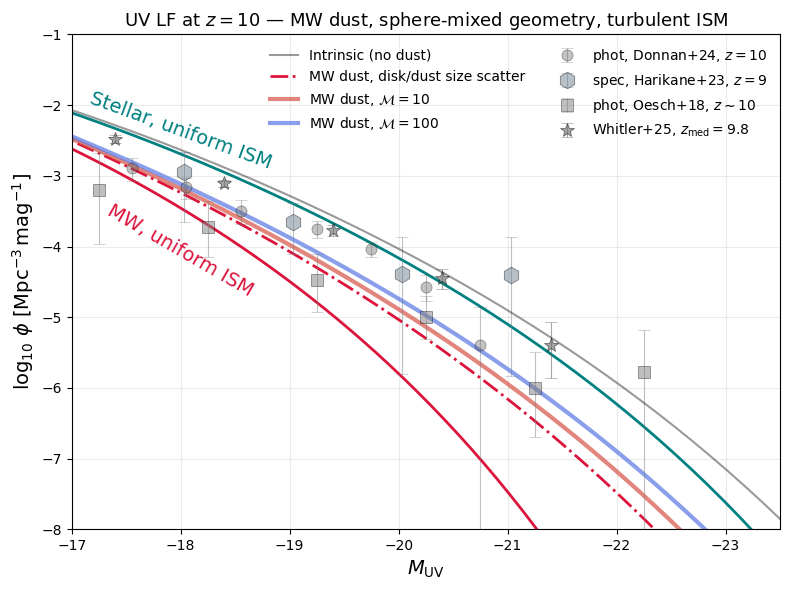

In [41]:
from scipy.special import erf
from scipy.signal import savgol_filter


# K_SPINS quantile seeds for geometry scatter (same scheme as main.py fig9)
K_SPINS_LF  = 21
mu_ln_sp    = np.log(10**-1.5677)
sig_ln_sp   = 0.5390
_ul         = (np.arange(1, K_SPINS_LF // 2 + 1) - 0.5) / K_SPINS_LF
u_lf        = np.concatenate([_ul, [0.5], 1.0 - _ul[::-1]])
spin_quant_lf = np.exp(mu_ln_sp + norm.ppf(u_lf) * sig_ln_sp)   # (K_SPINS_LF,)

# τ(T) lookup — start at 1e-3 to avoid T_sphere_mixed(0) undefined
tau_lu_grid = np.linspace(1e-3, 20.0, 4000)
T_lu_grid   = transmission_sphere_mixed(tau_lu_grid)
_T_rev      = T_lu_grid[::-1]
_tau_rev    = tau_lu_grid[::-1]

def _tau_of_T(t):
    return np.interp(np.clip(t, _T_rev[0], _T_rev[-1]), _T_rev, _tau_rev)

def _nz(x):
    return np.where(np.abs(x) < 1e-6, np.sign(x) * 1e-6, x)

# Halo mass function in log-space [Mpc^-3 dex^-1]
dn_dlogm_lf = halo_mass_function(masse, z_lf) * masse * np.log(10)
log_masse    = np.log10(masse)

kappa_UV = float(kappa_ext_tot[i_UV])   # MW dust UV opacity

# Geometry scatter: per-halo (Σ₀, σ_geom) from K_SPINS spin quantiles
Sigma0_lf     = np.empty(len(masse))
sigma_geom_lf = np.empty(len(masse))
for j, Mh in enumerate(masse):
    m_d   = f_d * eps_star * (Omb / OMm) * Mh   # M_dust [M_sun]
    r_d_k = np.array([disk_scale_length(z_lf, Mh, lam) for lam in spin_quant_lf])
    Sig_k = m_d * const.M_sun / ((4.0/3.0) * np.pi * r_d_k**2 * const.kpc**2)
    ln_s  = np.log(Sig_k)
    Sigma0_lf[j]     = np.exp(np.mean(ln_s))
    sigma_geom_lf[j] = np.std(ln_s)

# MUV grid spanning the intrinsic range
MUV_grid_lf = np.linspace(MUV_intr.min() - 0.5, MUV_intr.max() + 2.0, 300)
n_m_lf      = len(MUV_grid_lf)
n_mh_lf     = len(masse)

mach_lf_vals = [0, 10, 100]   # 0 = geometry/disk-size scatter only
phi_turb = {}

for mach in mach_lf_vals:
    sigma_turb_lf = lognormal_variance_from_mach(mach) if mach > 0 else 0.0
    sigma_eff_lf  = np.sqrt(sigma_geom_lf**2 + sigma_turb_lf**2)

    df_dm = np.zeros((n_mh_lf, n_m_lf))
    for j in range(n_mh_lf):
        M_int_j  = MUV_intr[j]
        Sig0_j   = Sigma0_lf[j]
        sigma_j  = sigma_eff_lf[j]
        if not (np.isfinite(Sig0_j) and Sig0_j > 0 and sigma_j > 0):
            continue

        T_star  = 10**(-0.4 * (MUV_grid_lf - M_int_j))
        valid_t = (T_star > 0) & (T_star <= 1.0)
        tau_max = np.zeros(n_m_lf)
        if np.any(valid_t):
            tau_max[valid_t] = _tau_of_T(T_star[valid_t])
        Sig_max = tau_max / kappa_UV

        f_mj = np.zeros(n_m_lf)
        pos  = Sig_max > 0
        if np.any(pos):
            z_ln       = (np.log(Sig_max[pos]) - np.log(Sig0_j)) / (np.sqrt(2.0) * sigma_j)
            f_mj[pos]  = 0.5 * (1.0 + erf(z_ln))

        df       = np.zeros(n_m_lf)
        df[1:-1] = (f_mj[2:] - f_mj[:-2]) / _nz(MUV_grid_lf[2:] - MUV_grid_lf[:-2])
        df[0]    = (f_mj[1] - f_mj[0])    / _nz(MUV_grid_lf[1]  - MUV_grid_lf[0])
        df[-1]   = (f_mj[-1] - f_mj[-2])  / _nz(MUV_grid_lf[-1] - MUV_grid_lf[-2])
        df_dm[j, :] = df

    phi_c = np.array([np.trapezoid(dn_dlogm_lf * df_dm[:, i], log_masse) for i in range(n_m_lf)])

    logphi   = np.log10(np.clip(phi_c, 1e-12, None))
    win_m    = max(11, min(41, (n_m_lf // 3) * 2 + 1))
    logphi_s = savgol_filter(logphi, win_m, 3, mode="interp")
    phi_s = 10**logphi_s
    for _i in range(1, len(phi_s)):
        if phi_s[_i] < phi_s[_i - 1]:
            phi_s[_i] = phi_s[_i - 1]
    phi_turb[mach] = phi_s

# ── Plot ──────────────────────────────────────────────────────────────────────
# coolwarm_r for Mach=10 and 100 — same normalisation as Section 6 histograms
_mach_plot = [10, 100]
# Match the explicit coolwarm_r positions used in Section 6 (M=10→0.1, M=100→0.9)
_mach_cols = [plt.cm.coolwarm_r(v) for v in [0.1, 0.9]]

fig, ax = plt.subplots(figsize=(8, 6))

# Intrinsic LF — identical style to Section 5
ax.plot(MUV_intr, np.log10(phi_intr), color="black", lw=1.5, ls="-",
        label="Intrinsic (no dust)", zorder=10, alpha=0.4)

# Reference lines from Section 5 — same color and linestyle, inline labels
ax.plot(MUV_mw_mix, np.log10(phi_mw_mix), color="crimson", lw=2, ls="-")
ax.plot(MUV_st_mix, np.log10(phi_st_mix), color="teal",    lw=2, ls="-")

# Inline text labels for the two uniform-ISM references — rotated to follow the line
# We need the figure rendered to use transData.transform for pixel-space angle
fig.canvas.draw()

ax.text(-18, -4.7,
        "MW, uniform ISM", color="crimson", fontsize=14, ha="center",
        rotation=-30)
ax.text(-18, -2.9,
        "Stellar, uniform ISM", color="teal", fontsize=14, ha="center",
        rotation=-20)

# Disk/dust size scatter (Mach=0) — grey dashed, matching Section 6 histogram style
ax.plot(MUV_grid_lf, np.log10(phi_turb[0]), color="crimson", lw=2, ls="-.",
        label=r"MW dust, disk/dust size scatter")

# Mach=10 and 100 — coolwarm_r, thicker and semi-transparent
for mach, col in zip(_mach_plot, _mach_cols):
    ax.plot(MUV_grid_lf, np.log10(phi_turb[mach]), color=col, lw=3, ls="-",
            alpha=0.7, label=fr"MW dust, $\mathcal{{M}}={mach}$")

# Observational data — per-source markers, black edgecolor (via plot_lf_data)
_plot_obs(ax, df_z10)

ax.set_xlabel(r"$M_{\rm UV}$", fontsize=14)
ax.set_ylabel(r"$\log_{10}\,\phi\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$", fontsize=14)
ax.set_xlim(-17.0, -23.5)
ax.set_ylim(-8, -1)
ax.legend(fontsize=10, frameon=False, ncol=2, loc="upper right")
ax.set_title(rf"UV LF at $z={z_lf:.0f}$ — MW dust, sphere-mixed geometry, turbulent ISM", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
print("Saving fig_uvlf_turbulent.pdf")
#fig.savefig(DATA_DIR / "../outputs/fig_uvlf_turbulent.pdf", bbox_inches="tight")
plt.show()